In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import math

import serial
import time

In [17]:
arduino = serial.Serial(port='COM3', baudrate=9600, timeout=1)
time.sleep(2)
prev_fingers_str = ""

In [18]:
def draw(image_name):
    plt.imshow(image_name)
    plt.axis('off')
    plt.show()

In [19]:
hands = {0: "Right", 1: "Left"}
landmarks = {0: "Wrist", 1: "Base of the thumb", 2: "Thumb knuckle", 3: "Thumb joint", 4: "Thumb tip", 5: "Index finger knuckle",
                6: "Index finger lower joint", 7: "Index finger upper joint", 8: "Index finger tip", 9: "Middle finger knuckle", 
                10: "Middle finger lower joint", 11: "Middle finger upper joint", 12: "Middle finger tip", 13: "Ring finger knuckle",
                14: "Ring finger lower joint", 15: "Ring finger upper joint", 16: "Ring finger tip", 17: "Pinky finger knuckle",
                18: "Pinky finger lower joint", 19: "Pinky finger upper joint", 20: "Pinky finger tip"}

color_group = [(226, 125, 96), (133, 220, 186),  (232, 168, 124),  (195, 141, 158),  (65, 179, 163)]

file_name = 'man.jpg'

In [20]:
image_rgb = cv2.cvtColor(cv2.imread(file_name), cv2.COLOR_BGR2RGB)

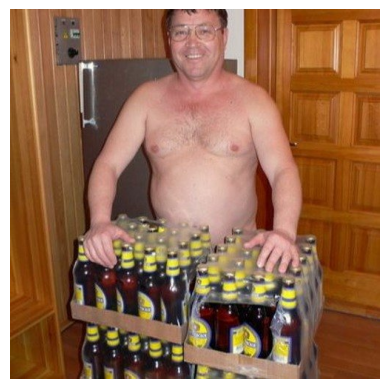

In [21]:
draw(image_rgb)

In [22]:
def draw_landmarks_on_image(img_pixel, result):
    not_conect = [3,7,11,15,19]
    annotated_image = np.copy(img_pixel)
    height, width, _ = annotated_image.shape
    if not result.hand_landmarks:
        return annotated_image
    for i in range(len(result.hand_landmarks)):
        hand = result.hand_landmarks[i]
        coords = [(int(landmark.x * width), int(landmark.y * height)) for landmark in hand]
        path = coords[:0:-1]
        counter, color_index = 0, 0
        color = color_group[color_index]
        for point, next_point in zip(path, path[1:]):
            cv2.circle(annotated_image, point, radius=3, color=color, thickness=-1)
            if counter not in not_conect:
                cv2.line(annotated_image, point, next_point, color=color, thickness=2)
            else: 
                color_index+=1
                color = color_group[color_index]
            counter+=1
        cv2.circle(annotated_image, path[-1], radius=3, color=(255,255,255), thickness=-1)
        for second_point in range(1,18,4):
             cv2.line(annotated_image, coords[0], coords[second_point], color=(255,255,255), thickness=2)
    return annotated_image

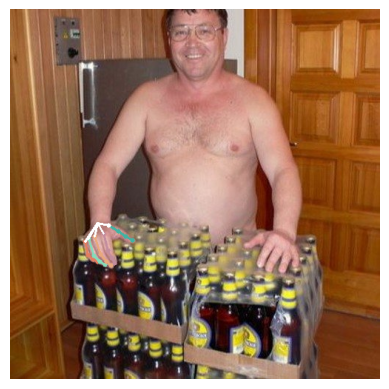

In [23]:
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

image = mp.Image.create_from_file(file_name)

detection_result = detector.detect(image)

annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
draw(annotated_image)

In [24]:
def get_raised_fingers(detection_result):
    if not detection_result.hand_landmarks:
        return [0, 0, 0, 0, 0]

    hand = detection_result.hand_landmarks[0]
    fingers = []
    
    def calc_dist(p1_idx, p2_idx):
        return math.hypot(hand[p1_idx].x - hand[p2_idx].x, hand[p1_idx].y - hand[p2_idx].y)
    
    if calc_dist(4, 17) > calc_dist(2, 17):
        fingers.append(1)
    else:
        fingers.append(0)

    tips, pips = [8, 12, 16, 20], [6, 10, 14, 18]

    for tip, pip in zip(tips, pips):
        if calc_dist(tip, 0) > calc_dist(pip, 0):
            fingers.append(1)
        else:
            fingers.append(0)

    return fingers

In [ ]:
import cv2
import time

MORSE_DICT = {
    '.-': 'A', '-...': 'B', '-.-.': 'C', '-..': 'D', '.': 'E',
    '..-.': 'F', '--.': 'G', '....': 'H', '..': 'I', '.---': 'J',
    '-.-': 'K', '.-..': 'L', '--': 'M', '-.': 'N', '---': 'O',
    '.--.': 'P', '--.-': 'Q', '.-.': 'R', '...': 'S', '-': 'T',
    '..-': 'U', '...-': 'V', '.--': 'W', '-..-': 'X', '-.--': 'Y',
    '--..': 'Z'
}

UNIT_T = 0.35 

current_morse_sequence = ""
decoded_text = ""         

fist_start_time = None     
open_start_time = time.time() 
was_fist = False            
letter_finalized = True    
space_added = True          

def process_morse_gesture(raised_fingers_list):
    global fist_start_time, open_start_time, was_fist
    global current_morse_sequence, decoded_text, letter_finalized, space_added
    
    current_time = time.time()

    is_fist = sum(raised_fingers_list) <= 1

    if is_fist and not was_fist:
        fist_start_time = current_time
        was_fist = True

    elif not is_fist and was_fist:
        duration = current_time - fist_start_time
        was_fist = False
        open_start_time = current_time
        letter_finalized = False
        space_added = False

        if duration >= (UNIT_T * 2.5):
            current_morse_sequence += "-"
        else:
            current_morse_sequence += "."

    elif not is_fist and not was_fist:
        pause_duration = current_time - open_start_time

        if pause_duration >= (UNIT_T * 3.0) and not letter_finalized:
            if current_morse_sequence:
                letter = MORSE_DICT.get(current_morse_sequence, "?")
                decoded_text += letter
                current_morse_sequence = ""
            letter_finalized = True

        if pause_duration >= (UNIT_T * 7.0) and not space_added:
            if decoded_text and not decoded_text.endswith(" "):
                decoded_text += " "
            space_added = True

    return current_morse_sequence, decoded_text

In [ ]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    detection_result = detector.detect(mp_image)
    
    annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
    final_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
    
    fingers = get_raised_fingers(detection_result)
    cv2.putText(final_image, str(fingers), (30, 70),
                cv2.FONT_HERSHEY_SCRIPT_SIMPLEX, 1.2, (0, 255, 255), 3, cv2.LINE_AA)
    
    curr_seq, text = process_morse_gesture(fingers)
    
    overlay = final_image.copy()
    cv2.rectangle(overlay, (15, 15), (620, 140), (20, 20, 20), -1)
    alpha = 0.6
    cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0, final_image)

    cv2.rectangle(final_image, (15, 15), (620, 140), (0, 255, 200), 2)

    morse_display = curr_seq if curr_seq else "[очікування...]"
    cv2.putText(final_image, f"Morse: {morse_display}", (30, 55), cv2.FONT_HERSHEY_SIMPLEX, 
                0.8, (0, 255, 255), 2, cv2.LINE_AA)
    
    text_display = text if text else "_"
    cv2.putText(final_image, f"Text:  {text_display}", (30, 95), cv2.FONT_HERSHEY_SIMPLEX, 
                0.9, (0, 255, 0), 2, cv2.LINE_AA)

    if fingers is not None and len(fingers) > 0:
        status_str = "HOLD FIST" if sum(fingers) <= 1 else "OPEN PALM"
        status_color = (0, 0, 255) if sum(fingers) <= 1 else (255, 200, 0)
        
        fingers_str = "".join(map(str, fingers))
        if fingers_str != prev_fingers_str:
            message = fingers_str + '\n'
            arduino.write(message.encode('utf-8'))
            prev_fingers_str = fingers_str
    else:
        status_str = "NO HAND"
        status_color = (100, 100, 100)

    cv2.putText(final_image, f"State: {status_str}", (30, 125), cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, status_color, 1, cv2.LINE_AA)
    
    cv2.imshow('Ruki nogi', final_image)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 